# Huấn luyện OCR hóa đơn tiếng Việt (MC-OCR 2021) trên Kaggle

Notebook này huấn luyện pipeline nhận dạng hóa đơn theo hướng:

- **[MC_OCR top-1](https://github.com/ndcuong91/MC_OCR)**: PaddleOCR phát hiện vùng chữ → VietOCR đọc nội dung → trích xuất trường (SELLER, ADDRESS, TIMESTAMP, TOTAL_COST).
- **[invoice_ocr_vietnamese](https://github.com/PakeNguyen/invoice_ocr_vietnamese)**: gom dòng + rule trích xuất tên quán, tổng tiền, ngày.

**Dataset Kaggle (bắt buộc thêm vào notebook):**

`/kaggle/input/datasets/domixi1989/vietnamese-receipts-mc-ocr-2021`

**Cài đặt trước khi chạy:**

1. Settings → Accelerator → **GPU** (T4/P100).
2. Add Data → dataset `vietnamese-receipts-mc-ocr-2021` (domixi1989).
3. Internet **On**.

**Đầu ra:** `/kaggle/working/receipt_ocr_artifacts/` — tải về chạy demo local.


## Giai đoạn 0 — Cài đặt thư viện

`vietocr==0.3.13` trên PyPI **ghim** `einops==0.2.0` — không cài `einops` mới hơn. Cài VietOCR trước, PaddleOCR sau.

**Python 3.12+ (Kaggle):** `paddlepaddle==3.2.2` + `paddleocr` 3.x; `enable_mkldnn=False` (tránh lỗi PIR/oneDNN).

PaddleOCR 3.x: dùng `predict(img)`, không dùng `ocr(img, cls=True)`.

Trên Kaggle, Paddle chạy **CPU** (detection); VietOCR vẫn dùng **GPU**.


In [1]:
# %% [Giai đoạn 0] Cài đặt
import importlib.util
import subprocess
import sys

def pip(*packages, reinstall=False):
    cmd = [sys.executable, "-m", "pip", "install", "-q"]
    if reinstall:
        cmd.extend(["--force-reinstall", "--no-cache-dir"])
    subprocess.check_call(cmd + list(packages))

# 1) VietOCR (kéo einops==0.2.0, pillow==10.2.0, ...)
pip("vietocr==0.3.13")

# 2–3) Paddle runtime + PaddleOCR (phụ thuộc phiên bản Python)
import os

# Trước import paddle: tránh PIR+oneDNN crash trên CPU (Paddle 3.3+)
os.environ.setdefault("FLAGS_use_mkldnn", "0")
os.environ.setdefault("PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK", "True")

PADDLE_CPU_INDEX = "https://www.paddlepaddle.org.cn/packages/stable/cpu/"
PY312 = sys.version_info >= (3, 12)


def _uninstall_paddle_wheels():
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-y", "paddlepaddle", "paddlepaddle-gpu"],
        capture_output=True,
    )


def _install_paddle():
    on_kaggle = os.path.isdir("/kaggle")
    # Python 3.12: chỉ có wheel Paddle 3.x; 2.6.1 không cài được.
    if PY312 or on_kaggle:
        _uninstall_paddle_wheels()
        if PY312:
            pip("setuptools>=68.0.0")
        pip(
            "paddlepaddle==3.2.2",
            "-i",
            PADDLE_CPU_INDEX,
        )
        return
    if importlib.util.find_spec("paddle") is not None:
        return
    try:
        pip(
            "paddlepaddle-gpu==2.6.1",
            "-f",
            "https://www.paddlepaddle.org.cn/whl/linux/mkl/avx/stable.html",
        )
    except subprocess.CalledProcessError:
        pip("paddlepaddle==2.6.1")


def _install_paddleocr():
    if PY312:
        pip("paddleocr>=3.0.0,<4.0.0")
    else:
        pip("paddleocr>=2.7.0,<3.0.0")


def _install_paddlex_extras():
    # PaddleOCR 3.x kéo paddlex → cần langchain_text_splitters (optional dep chưa khai báo đủ)
    if not PY312:
        return
    pip("langchain-text-splitters")
    pip("langchain", "langchain-community")


_install_paddle()
_install_paddleocr()
_install_paddlex_extras()

# 4) Sửa PIL lệch bản (vietocr pin 10.2.0 + paddleocr → file PIL lẫn version)
def _fix_pillow():
    for ver in ("10.4.0", "11.1.0"):
        pip(f"Pillow=={ver}", reinstall=True)
        try:
            import importlib
            import PIL.ImageFont  # noqa: F401
            from PIL import Image
            print("Pillow:", Image.__version__)
            return
        except ImportError:
            pass
    raise RuntimeError("Không sửa được Pillow — restart session và chạy lại cell 0.")

_fix_pillow()


def _patch_numpy_for_imgaug():
    # imgaug 0.4.0 dùng np.sctypes (đã bỏ ở NumPy 2; Kaggle không hạ được numpy<2)
    import numpy as np

    if hasattr(np, "sctypes"):
        return
    np.sctypes = {
        "float": [np.float16, np.float32, np.float64],
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, object, bytes, str],
    }


_patch_numpy_for_imgaug()
import numpy as np

print("NumPy:", np.__version__)

import torch

print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

import einops
import vietocr
from vietocr.model.trainer import Trainer  # sau _patch_numpy_for_imgaug()
import paddle
from paddleocr import PaddleOCR

print("einops:", einops.__version__)
print("vietocr:", getattr(vietocr, "__version__", "0.3.13"))
print("Paddle:", paddle.__version__)
print("PaddleOCR + VietOCR Trainer: OK")
# Cảnh báo pip khác từ gói sẵn Kaggle — bỏ qua nếu import OK.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 27.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 79.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.1 requires PyYAML<6.1,>=6.0.3, but you have pyyaml 6.0.2 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 50.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vietocr 0.3.13 requires pillow==10.2.0, but you have pillow 10.4.0 which is incompatible.
ydata-profiling 4.18.1 requires PyYAML<6.1,>=6.0.3, but you have pyyaml 6.0.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


Pillow: 11.3.0
NumPy: 2.0.2
PyTorch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


einops: 0.2.0
vietocr: 0.3.13
Paddle: 3.2.2
PaddleOCR + VietOCR Trainer: OK


## Giai đoạn 1 — Đường dẫn dataset & khám phá dữ liệu (EDA)

Dataset MC-OCR: ~1155 ảnh train, crop dòng chữ, CSV nhãn trường.


Dataset root: /kaggle/input/datasets/domixi1989/vietnamese-receipts-mc-ocr-2021
Train images: /kaggle/input/datasets/domixi1989/vietnamese-receipts-mc-ocr-2021/train_images/train_images → 1155
Val images: /kaggle/input/datasets/domixi1989/vietnamese-receipts-mc-ocr-2021/val_images/val_images → 391
Text crops: /kaggle/input/datasets/domixi1989/vietnamese-receipts-mc-ocr-2021/text_recognition_mcocr_data/text_recognition_mcocr_data → 6585
mcocr_train_df: (1155, 6)
Top labels: [('TOTAL_COST', 2114), ('ADDRESS', 1952), ('TIMESTAMP', 1347), ('SELLER', 1171), ('', 2), ('TOTAL_TOTAL_COST', 1)]


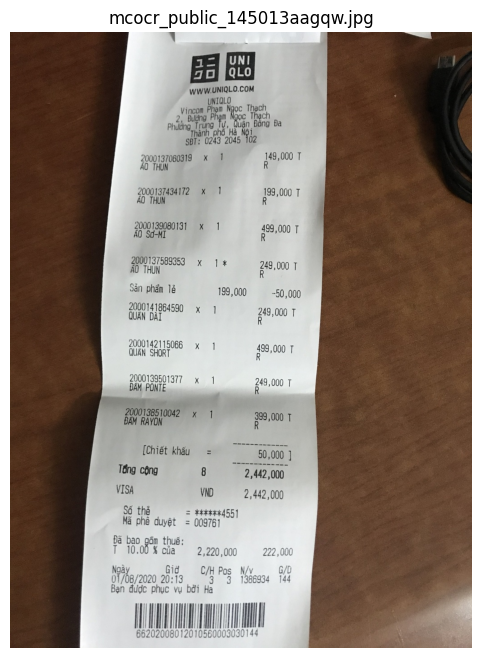

In [2]:
# %% [Giai đoạn 1] EDA
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

KAGGLE_ROOT = Path("/kaggle/input/datasets/domixi1989/vietnamese-receipts-mc-ocr-2021")
if not KAGGLE_ROOT.is_dir():
    KAGGLE_ROOT = Path("/kaggle/input/vietnamese-receipts-mc-ocr-2021")
assert KAGGLE_ROOT.is_dir(), (
    "Thêm dataset domixi1989/vietnamese-receipts-mc-ocr-2021 vào notebook"
)


def nested(root: Path, name: str) -> Path:
    direct, inner = root / name, root / name / name
    return inner if inner.is_dir() else direct


TRAIN_IMG_DIR = nested(KAGGLE_ROOT, "train_images")
VAL_IMG_DIR = nested(KAGGLE_ROOT, "val_images")
CROP_DIR = nested(KAGGLE_ROOT, "text_recognition_mcocr_data")
TRAIN_CSV = KAGGLE_ROOT / "mcocr_train_df.csv"
TRAIN_ANN = KAGGLE_ROOT / "text_recognition_train_data.txt"
VAL_ANN = KAGGLE_ROOT / "text_recognition_val_data.txt"

WORK = Path("/kaggle/working")
ARTIFACTS = WORK / "receipt_ocr_artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

n_train = len(list(TRAIN_IMG_DIR.glob("*.jpg")))
n_val = len(list(VAL_IMG_DIR.glob("*.jpg")))
n_crop = len(list(CROP_DIR.glob("*.jpg")))

print("Dataset root:", KAGGLE_ROOT)
print("Train images:", TRAIN_IMG_DIR, "→", n_train)
print("Val images:", VAL_IMG_DIR, "→", n_val)
print("Text crops:", CROP_DIR, "→", n_crop)
assert n_crop > 0, "Không thấy crop ảnh — kiểm tra đường dẫn text_recognition_mcocr_data"

df = pd.read_csv(TRAIN_CSV)
print("mcocr_train_df:", df.shape)

label_counts = {}
for s in df["anno_labels"].fillna(""):
    for lab in str(s).split("|||"):
        label_counts[lab] = label_counts.get(lab, 0) + 1
print("Top labels:", sorted(label_counts.items(), key=lambda x: -x[1])[:10])

samples = sorted(TRAIN_IMG_DIR.glob("*.jpg"))
assert samples, "Không có ảnh train"
fig, ax = plt.subplots(1, 1, figsize=(6, 8))
ax.imshow(plt.imread(samples[0]))
ax.set_title(samples[0].name)
ax.axis("off")
plt.show()


## Giai đoạn 2 — Chuẩn bị dữ liệu fine-tune VietOCR

VietOCR cần `data_root` chứa ảnh + file annotation. **Không** symlink cả thư mục `images` vào `/kaggle/input` (read-only) — chỉ symlink từng file `.jpg` vào `/kaggle/working`.


In [3]:
# %% [Giai đoạn 2] Chuẩn bị annotation VietOCR
import shutil

OCR_DATA = WORK / "vietocr_data"
if OCR_DATA.exists():
    shutil.rmtree(OCR_DATA)
OCR_DATA.mkdir(parents=True)

img_root = OCR_DATA / "images"
img_root.mkdir(parents=True, exist_ok=True)

# Thư mục trong /kaggle/working (ghi được). Symlink từng crop → input read-only.
crop_files = list(CROP_DIR.glob("*.jpg"))
print(f"Liên kết {len(crop_files)} ảnh crop vào {img_root} ...")
linked, copied = 0, 0
for src in crop_files:
    dst = img_root / src.name
    if dst.exists() or dst.is_symlink():
        continue
    try:
        dst.symlink_to(src)
        linked += 1
    except OSError:
        shutil.copy2(src, dst)
        copied += 1
print(f"  symlink: {linked} | copy: {copied}")

assert any(img_root.glob("*.jpg")), f"Thư mục ảnh trống: {img_root}"


def build_ann(src_txt: Path, dst_txt: Path) -> int:
    lines_out = []
    missing = 0
    with open(src_txt, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or "	" not in line:
                continue
            fname, label = line.split("	", 1)
            fname, label = fname.strip(), label.strip()
            if not label:
                continue
            img_path = img_root / fname
            if not img_path.is_file():
                missing += 1
                continue
            label = label.replace("	", " ")
            lines_out.append(f"{fname}	{label}")
    dst_txt.parent.mkdir(parents=True, exist_ok=True)
    dst_txt.write_text(chr(10).join(lines_out), encoding="utf-8")
    print(dst_txt.name, "lines:", len(lines_out), "| missing:", missing)
    return len(lines_out)


train_ann = img_root / "train_annotation.txt"
val_ann = img_root / "val_annotation.txt"
n_tr = build_ann(TRAIN_ANN, train_ann)
n_va = build_ann(VAL_ANN, val_ann)
assert n_tr > 0 and n_va > 0, "Annotation rỗng — kiểm tra file txt và thư mục crop"

print("Sample:")
print(train_ann.read_text(encoding="utf-8").splitlines()[:3])


Liên kết 6585 ảnh crop vào /kaggle/working/vietocr_data/images ...
  symlink: 6585 | copy: 0
train_annotation.txt lines: 5285 | missing: 0
val_annotation.txt lines: 1300 | missing: 0
Sample:
['mcocr_public_145013snoxg_0.jpg\tTHE COFFEE HOUSE', 'mcocr_public_145013snoxg_1.jpg\t403 Phan Huy Ích, P.14, QGò Vấp', 'mcocr_public_145013snoxg_2.jpg\tThời gian: 30:09:202009.202009.30']


## Giai đoạn 3 — Fine-tune VietOCR (vgg_transformer)

Huấn luyện từ pretrained. LMDB cache tạo tại `/kaggle/working` (đổi cwd trước khi train).


In [4]:
# %% [Giai đoạn 3] Train VietOCR
import os
import shutil
from pathlib import Path

# Shim NumPy 2 cho imgaug (nếu chạy lại cell 3 mà không chạy cell 0)
def _patch_numpy_for_imgaug():
    import numpy as np

    if hasattr(np, "sctypes"):
        return
    np.sctypes = {
        "float": [np.float16, np.float32, np.float64],
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, object, bytes, str],
    }


_patch_numpy_for_imgaug()

from vietocr.tool.config import Cfg
from vietocr.model.trainer import Trainer

BATCH_SIZE = 16  # giảm nếu OOM trên T4
NUM_ITERS = 8000
VALID_EVERY = 2000
PRINT_EVERY = 200

VIETOCR_DATA_ROOT = str(img_root) + os.sep

config = Cfg.load_config_from_name("vgg_transformer")
config["device"] = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
config["cnn"]["pretrained"] = False

config["dataset"].update({
    "name": "mcocr_receipt",
    "data_root": VIETOCR_DATA_ROOT,
    "train_annotation": "train_annotation.txt",
    "valid_annotation": "val_annotation.txt",
})

config["trainer"].update({
    "batch_size": BATCH_SIZE,
    "print_every": PRINT_EVERY,
    "valid_every": VALID_EVERY,
    "iters": NUM_ITERS,
    "checkpoint": str(ARTIFACTS / "vietocr_checkpoint.pth"),
    "export": str(ARTIFACTS / "vietocr_receipt.pth"),
    "log": str(ARTIFACTS / "train.log"),
})
config["dataloader"]["num_workers"] = 0  # ổn định trên Kaggle

config_path = ARTIFACTS / "config.yml"
export_path = Path(config["trainer"]["export"])
ckpt_path = Path(config["trainer"]["checkpoint"])

# LMDB tạo trong cwd → chạy từ /kaggle/working
_orig_cwd = os.getcwd()
os.chdir(WORK)
try:
    trainer = Trainer(config, pretrained=True)
    trainer.config.save(str(config_path))
    print("Saved config:", config_path)
    trainer.train()
finally:
    os.chdir(_orig_cwd)

# Luôn có weights export (kể cả khi val acc không tăng)
if not export_path.is_file():
    if ckpt_path.is_file():
        shutil.copy(ckpt_path, export_path)
        print("Copied checkpoint → export:", export_path)
    else:
        trainer.save_weights(str(export_path))
        print("Saved final weights:", export_path)

assert export_path.is_file(), "Không tạo được vietocr_receipt.pth"
print("Export size (MB):", round(export_path.stat().st_size / 1e6, 2))


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:13, 1338.43it/s]
Create train_mcocr_receipt: 100%|██████████████████████████████| 5285/5285 [00:18<00:00, 285.99it/s]

Created dataset with 5284 samples



Create valid_mcocr_receipt: 100%|██████████████████████████████| 1300/1300 [00:04<00:00, 275.90it/s]

Created dataset with 1299 samples



valid_mcocr_receipt build cluster: 100%|████████████████████| 1299/1299 [00:00<00:00, 112377.55it/s]


Saved config: /kaggle/working/receipt_ocr_artifacts/config.yml
iter: 000200 - train loss: 0.812 - lr: 5.43e-05 - load time: 3.56 - gpu time: 27.25
iter: 000400 - train loss: 0.731 - lr: 1.56e-04 - load time: 3.55 - gpu time: 26.68
iter: 000600 - train loss: 0.720 - lr: 2.58e-04 - load time: 3.52 - gpu time: 27.67
iter: 000800 - train loss: 0.713 - lr: 3.00e-04 - load time: 3.52 - gpu time: 28.26
iter: 001000 - train loss: 0.689 - lr: 2.99e-04 - load time: 3.55 - gpu time: 27.88
iter: 001200 - train loss: 0.700 - lr: 2.98e-04 - load time: 3.50 - gpu time: 27.60
iter: 001400 - train loss: 0.688 - lr: 2.95e-04 - load time: 3.49 - gpu time: 28.84
iter: 001600 - train loss: 0.687 - lr: 2.91e-04 - load time: 3.59 - gpu time: 28.07
iter: 001800 - train loss: 0.671 - lr: 2.86e-04 - load time: 3.51 - gpu time: 27.85
iter: 002000 - train loss: 0.664 - lr: 2.80e-04 - load time: 3.65 - gpu time: 27.53
iter: 002000 - valid loss: 0.663 - acc full seq: 0.6990 - acc per char: 0.8766
iter: 002200 - tra

## Giai đoạn 4 — Đánh giá nhanh trên ảnh validation

PaddleOCR detect + VietOCR đã fine-tune + rule trích xuất trường.


In [5]:
# %% [Giai đoạn 4] Đánh giá mẫu
import os
import re
import sys

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from vietocr.tool.config import Cfg
from vietocr.tool.predictor import Predictor

"""PaddleOCR 2.x / 3.x compatibility helpers (CPU, no MKLDNN on Py3.12+)."""
from __future__ import annotations

import os
import sys
from typing import Any

import numpy as np

PY312 = sys.version_info >= (3, 12)


def setup_paddle_env() -> None:
    """Call before `import paddle` / PaddleOCR (PIR+oneDNN bug on Paddle 3.3+ CPU)."""
    os.environ.setdefault("FLAGS_use_mkldnn", "0")
    os.environ.setdefault("PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK", "True")


def paddle_ocr_init_kwargs(use_gpu: bool) -> dict[str, Any]:
    kw: dict[str, Any] = dict(lang="vi", use_gpu=use_gpu, enable_mkldnn=False)
    if PY312:
        kw.update(
            use_doc_orientation_classify=False,
            use_doc_unwarping=False,
            use_textline_orientation=False,
        )
    else:
        kw["use_angle_cls"] = True
    return kw


def init_paddleocr(use_gpu: bool | None = None):
    from paddleocr import PaddleOCR

    if use_gpu is None:
        use_gpu = not os.path.isdir("/kaggle")
    base = paddle_ocr_init_kwargs(use_gpu)
    attempts = [
        base,
        dict(lang="vi", use_gpu=use_gpu, enable_mkldnn=False),
        dict(lang="vi", enable_mkldnn=False),
        dict(lang="vi"),
    ]
    last_err: Exception | None = None
    for kwargs in attempts:
        try:
            return PaddleOCR(**kwargs)
        except (TypeError, ValueError) as exc:
            last_err = exc
    assert last_err is not None
    raise last_err


def run_paddle_ocr(engine, image: np.ndarray):
    if hasattr(engine, "predict"):
        raw = engine.predict(image)
        return list(raw) if raw is not None else []
    return engine.ocr(image)


def _res_dict(item: Any) -> dict[str, Any] | None:
    if isinstance(item, dict):
        return item.get("res", item)
    for attr in ("json", "res"):
        if not hasattr(item, attr):
            continue
        val = getattr(item, attr)
        if callable(val):
            val = val()
        if isinstance(val, dict):
            return val.get("res", val)
    return None


def paddle_lines(ocr_result: Any) -> list[list[Any]]:
    if not ocr_result:
        return []
    # PaddleOCR 2.x: [page] where page = [[box, (text, conf)], ...]
    if isinstance(ocr_result[0], (list, tuple)):
        page = ocr_result[0]
        if page:
            first = page[0]
            if (
                isinstance(first, (list, tuple))
                and len(first) >= 2
                and isinstance(first[0], (list, tuple))
                and len(first[0]) >= 2
            ):
                return list(page)
    lines: list[list[Any]] = []
    for item in ocr_result:
        data = _res_dict(item)
        if not data:
            continue
        polys = data.get("rec_polys") or data.get("dt_polys") or []
        texts = list(data.get("rec_texts") or [])
        scores = list(data.get("rec_scores") or [])
        for i, poly in enumerate(polys):
            box = np.asarray(poly).tolist()
            text = texts[i] if i < len(texts) else ""
            conf = float(scores[i]) if i < len(scores) else 0.0
            lines.append([box, (text, conf)])
    return lines



def extract_receipt_fields(df_lines: pd.DataFrame) -> dict:
    lines = [str(x).strip() for x in df_lines["line_text"].tolist() if str(x).strip()]
    info = {"seller": None, "address": None, "timestamp": None, "total_cost": None}
    if not lines:
        return info
    for line in lines[:5]:
        low = line.lower()
        if "ngày" not in low and "tổng" not in low and "tong" not in low:
            info["seller"] = line
            break
    for line in lines:
        if re.search(r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}", line):
            info["timestamp"] = line
            break
    amounts = []
    for line in reversed(lines):
        for n in re.findall(r"[\d.,]+", line):
            d = re.sub(r"\D", "", n)
            if d and int(d) >= 1000:
                amounts.append(int(d))
    if amounts:
        info["total_cost"] = max(amounts)
    return info


weights = export_path
assert weights.is_file(), f"Thiếu weights: {weights} — chạy lại giai đoạn 3"

cfg = Cfg.load_config_from_file(str(config_path))
cfg["weights"] = str(weights)
cfg["device"] = config["device"]
cfg["cnn"]["pretrained"] = False
predictor = Predictor(cfg)
paddle = init_paddleocr(use_gpu=not os.path.isdir("/kaggle"))


def pipeline_one(img_path):
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        raise FileNotFoundError(img_path)
    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    res = run_paddle_ocr(paddle, img)
    rows = []
    for line in paddle_lines(res):
        box, rec = line
        tp, conf = rec if isinstance(rec, (list, tuple)) else (str(rec), 0.0)
        xs = [p[0] for p in box]
        ys = [p[1] for p in box]
        x1, y1 = int(min(xs)), int(min(ys))
        x2, y2 = int(max(xs)), int(max(ys))
        if x2 <= x1 or y2 <= y1:
            continue
        crop = img[y1:y2, x1:x2]
        try:
            text = predictor.predict(Image.fromarray(crop)) or tp
        except Exception:
            text = tp
        rows.append({"x1": x1, "y1": y1, "x2": x2, "y2": y2, "text": str(text).strip()})
    df = pd.DataFrame(rows)
    if df.empty:
        return {}, df
    df = df.sort_values("y1")
    groups, cur, last_y = [], [], -1e9
    for _, r in df.iterrows():
        yc = (r["y1"] + r["y2"]) / 2
        if abs(yc - last_y) > 30 and cur:
            groups.append(cur)
            cur = []
        cur.append(r.to_dict())
        last_y = yc
    if cur:
        groups.append(cur)
    line_texts = []
    for grp in groups:
        grp = sorted(grp, key=lambda x: x["x1"])
        line_texts.append(" ".join(x["text"] for x in grp if x["text"]))
    df_lines = pd.DataFrame({"line_text": line_texts})
    return extract_receipt_fields(df_lines), df_lines


val_samples = sorted(VAL_IMG_DIR.glob("*.jpg"))[:5]
assert val_samples, "Không có ảnh validation"
for p in val_samples:
    fields, lines = pipeline_one(p)
    print("---", p.name)
    print("Extracted:", fields)
    if not lines.empty:
        print(lines["line_text"].tolist()[:8])


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Connectivity check to the model hoster has been skipped because `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` is enabled.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


...

Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('latin_PP-OCRv5_mobile_rec', None, None)
Using official model (latin_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/latin_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

--- mcocr_val_145114anqqj.jpg
Extracted: {'seller': 'Booker Phart', 'address': None, 'timestamp': 'Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu DA Tang 1 13 Trye Dine in shier H de te : 16-08-2020 - 10:30', 'total_cost': 65000}
['Booker Phart', 'Tổ 43 Tô Ngọc Vận ( Hest Lake Tang 1,SH42 - Toa K3, Cong trinh chung cu 1860 14', 'T INVOIA', 'Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu DA Tang 1 13 Trye Dine in shier H de te : 16-08-2020 - 10:30', 'Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu Tang 1,SH42 - Toa K3, Cong trinh chung cu Mango Eart Tang 3 Qty Discount Tang 1,SH42 - Toa K3, Cong trinh chung cu 000', 'Dang 2.2020 Le Tang 1,SH42 - Toa K3, Cong trinh chung cu

## Giai đoạn 5 — Đóng gói artifact & lưu Kaggle Output

Tải `receipt_ocr_artifacts.zip` về `Train/OCR/models/` để chạy demo.


In [6]:
# %% [Giai đoạn 5] Lưu artifact
import json
import zipfile

meta = {
    "dataset": str(KAGGLE_ROOT),
    "train_images": n_train,
    "val_images": n_val,
    "text_crops": n_crop,
    "vietocr_weights": "vietocr_receipt.pth",
    "config": "config.yml",
    "num_iters": NUM_ITERS,
    "batch_size": BATCH_SIZE,
}
(ARTIFACTS / "meta.json").write_text(
    json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8"
)

zip_path = WORK / "receipt_ocr_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in ARTIFACTS.rglob("*"):
        if f.is_file():
            zf.write(f, f.relative_to(ARTIFACTS.parent))

print("Artifacts in", ARTIFACTS)
for f in sorted(ARTIFACTS.iterdir()):
    if f.is_file():
        print(f"  {f.name}: {f.stat().st_size // 1024} KB")
print("Zip:", zip_path, "→", zip_path.stat().st_size // 1024, "KB")


Artifacts in /kaggle/working/receipt_ocr_artifacts
  config.yml: 1 KB
  meta.json: 0 KB
  train.log: 3 KB
  vietocr_receipt.pth: 148253 KB
Zip: /kaggle/working/receipt_ocr_artifacts.zip → 138357 KB


## Giai đoạn 6 — Demo local (sau khi tải artifact)

```powershell
cd D:\Luan-Van\Train
.\.venv\Scripts\Activate.ps1
pip install -r OCR\requirements.txt
# Giải nén receipt_ocr_artifacts.zip → OCR\models\
$env:RECEIPT_OCR_WEIGHTS = "D:\Luan-Van\Train\OCR\models\vietocr_receipt.pth"
cd OCR\demo
uvicorn server:app --reload --host 127.0.0.1 --port 8010
```

Mở http://127.0.0.1:8010
